# Zadanie 03 - `Analiza tekstów medycznych: rozpoznawanie jednostek medycznych i klasyfikacja dokumentów za pomoca NLP`

In [2]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Próba załadowania spaCy
try:
    import spacy
    from spacy.lang.en import English
    from spacy.pipeline import EntityRuler
    SPACY_AVAILABLE = True
except ImportError:
    SPACY_AVAILABLE = False
    print("spaCy niedostępne — użyjemy fallbacku słownikowego (NER oparty na słowniku).")

plt.rcParams["figure.figsize"] = (7, 4)

print("Środowisko gotowe.")

Środowisko gotowe.


## Etap 1: Przygotowanie danych tekstowych

In [36]:
df = pd.read_csv("variant_02_diabetes.csv")
print("Zbiór danych:")
print(df)

Zbiór danych:
                                                text label
0  Type 2 diabetes diagnosed 5 years ago. HbA1c =...  endo
1  Newly diagnosed type 1 diabetes in young adult...  endo
2  Long-term diabetic with neuropathy and retinop...  endo
3  Patient with well-controlled type 2 diabetes o...  endo
4  Diabetic ketoacidosis on admission. pH 7.15, g...  endo


In [37]:

# Funkcja czyszcząca
def clean_text(s):
    s = s.lower()
    s = s.replace("\n", " ").replace("\t", " ")
    s = re.sub(r"https?://\S+", " ", s)
    # usuwanie jednostki mg, ml itp. (zachowując nazwy leków)
    s = re.sub(r"\b\d+(?:\.\d+)?\s*(?:mg|ml|g|mmol/l|mg/dl)\b", " dose ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean"] = df["text"].apply(clean_text)
# df.head()

In [38]:
def build_spacy_pipeline():
    nlp = English()
    ruler = nlp.add_pipe("entity_ruler")
    patterns = [
        {"label": "DISEASE", "pattern": "pneumonia"},
        {"label": "DISEASE", "pattern": "diabetes"},
        {"label": "DISEASE", "pattern": "stroke"},
        {"label": "DISEASE", "pattern": "myocardial infarction"},
        {"label": "DRUG", "pattern": "aspirin"},
        {"label": "DRUG", "pattern": "metformin"},
        {"label": "DRUG", "pattern": "amoxicillin"},
        {"label": "DRUG", "pattern": "lisinopril"},
        {"label": "DRUG", "pattern": "statin"},
        {"label": "TEST", "pattern": "ecg"},
        {"label": "TEST", "pattern": "mri"},
        {"label": "TEST", "pattern": "ct scan"},
        {"label": "TEST", "pattern": "troponin"},
        {"label": "TEST", "pattern": "endoscopy"},
        {"label": "TEST", "pattern": "hba1c"}
    ]
    ruler.add_patterns(patterns)
    return nlp

# Tokenizacja (prosta, a jeśli spaCy – lematyzacja)
if SPACY_AVAILABLE:
    try:
        nlp = build_spacy_pipeline()
        tokens = [[t.text for t in nlp(text)] for text in df["clean"].tolist()]
        df["tokens"] = tokens
        print("spaCy pipeline działa (EntityRuler).")
    except Exception as e:
        print("Błąd spaCy, używam prostego split:", e)
        df["tokens"] = df["clean"].str.split()
else:
    df["tokens"] = df["clean"].str.split()

print("\nPrzykład czyszczenia i tokenizacji:")
print(df[["clean", "tokens"]].head(5))

spaCy pipeline działa (EntityRuler).

Przykład czyszczenia i tokenizacji:
                                               clean  \
0  type 2 diabetes diagnosed 5 years ago hba1c 82...   
1  newly diagnosed type 1 diabetes in young adult...   
2  longterm diabetic with neuropathy and retinopa...   
3  patient with wellcontrolled type 2 diabetes on...   
4  diabetic ketoacidosis on admission ph 715 gluc...   

                                              tokens  
0  [type, 2, diabetes, diagnosed, 5, years, ago, ...  
1  [newly, diagnosed, type, 1, diabetes, in, youn...  
2  [longterm, diabetic, with, neuropathy, and, re...  
3  [patient, with, wellcontrolled, type, 2, diabe...  
4  [diabetic, ketoacidosis, on, admission, ph, 71...  


## Etap 2: Rozpoznawanie jednostek medycznych (NER)

In [45]:
# Słownik medycznych encji
lex = {
        "DISEASE": ["pneumonia", "diabetes", "stroke", "myocardial infarction", "hypertension", "asthma"],
        "DRUG": ["aspirin", "metformin", "amoxicillin", "lisinopril", "statin", "ppi", "salbutamol"],
        "TEST": ["ecg", "mri", "ct", "ct scan", "troponin", "endoscopy", "hba1c"]
    }

def simple_ner(text):
    """Znajduje encje na podstawie słownika."""
    text_low = text.lower()
    entities = []
    for label, words in lex.items():
        for w in words:
            if w in text_low:
                entities.append((w, label))
    # Usuwanie duplikatów (gdy jeden fragment pasuje do wielu słów)
    # oraz sortowanie po długości malejąco (do podświetlania)
    entities = list(set(entities))
    entities.sort(key=lambda x: len(x[0]), reverse=True)
    return entities

if SPACY_AVAILABLE:
    try:
        ents_demo = []
        for text in df["clean"].tolist():
            doc = nlp(text)
            ents_demo.append([(ent.text, ent.label_) for ent in doc.ents])
        df["entities"] = ents_demo
    except Exception as e:
        print("spaCy NER demo nie działa – fallback:", e)
        df["entities"] = df["clean"].apply(simple_ner)
else:
    df["entities"] = df["clean"].apply(simple_ner)

df[["text", "entities"]].head(10)

,text,entities
0,Type 2 diabetes diagnosed 5 years ago. HbA1c =...,"[(diabetes, DISEASE), (hba1c, TEST), (metformi..."
1,Newly diagnosed type 1 diabetes in young adult...,"[(diabetes, DISEASE)]"
2,Long-term diabetic with neuropathy and retinop...,[]
3,Patient with well-controlled type 2 diabetes o...,"[(diabetes, DISEASE), (metformin, DRUG), (hba1..."
4,"Diabetic ketoacidosis on admission. pH 7.15, g...",[]


In [46]:

# Wyświetlenie przykładowych encji
print("\nPrzykładowe encje medyczne:")
for idx, row in df.iterrows():
    print(f"Dokument {idx+1}: {row['entities']}")



Przykładowe encje medyczne:
Dokument 1: [('diabetes', 'DISEASE'), ('hba1c', 'TEST'), ('metformin', 'DRUG')]
Dokument 2: [('diabetes', 'DISEASE')]
Dokument 3: []
Dokument 4: [('diabetes', 'DISEASE'), ('metformin', 'DRUG'), ('hba1c', 'TEST')]
Dokument 5: []


## Etap 3: Klasyfikacja dokumentów (TF–IDF + Logistic Regression)

In [50]:
# Klasyfikacja – obsługa przypadku 1 klasy
X = df["clean"].values
y = df["label"].values

# W tym zbiorze wszystkie etykiety to "endo" – klasyfikacja trywialna.
unique_classes = np.unique(y)

if len(unique_classes) == 1:
    print("\nUWAGA: Zbiór zawiera tylko jedną klasę:", unique_classes[0])
    print("Klasyfikacja nie jest potrzebna – wszystkie dokumenty należą do tej samej kategorii.")
    # Sztuczne przewidywania (wszystkie testowe jako jedyna klasa)
    from sklearn.dummy import DummyClassifier
    dummy = DummyClassifier(strategy="constant", constant=unique_classes[0])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Dokładność (trywialna): {acc:.3f}")
    print("\nRaport klasyfikacji (tylko jedna klasa):")
    # Ręczne zbudowanie raportu dla jednej klasy
    print(f"{'':12} precision    recall  f1-score   support")
    print(f"{unique_classes[0]:12}     1.000     1.000     1.000     {len(y_test)}")
    print(f"\naccuracy                            1.000     {len(y_test)}")
    print(f"macro avg       1.000     1.000     1.000     {len(y_test)}")
    print(f"weighted avg    1.000     1.000     1.000     {len(y_test)}")
else:
    # Normalny podział stratyfikowany
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Wektoryzacja TF-IDF (unigramy i bigramy)
    vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Klasyfikator – regresja logistyczna
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    # Ocena modelu
    acc = accuracy_score(y_test, y_pred)
    print(f"\nDokładność klasyfikacji: {acc:.3f}")
    print("\nRaport klasyfikacji:")
    print(classification_report(y_test, y_pred, digits=3))

    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred, labels=sorted(unique_classes))
    plt.figure()
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Macierz pomyłek – klasyfikacja dokumentów")
    plt.colorbar()
    tick_marks = np.arange(len(unique_classes))
    plt.xticks(tick_marks, sorted(unique_classes))
    plt.yticks(tick_marks, sorted(unique_classes))
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.ylabel("Rzeczywiste")
    plt.xlabel("Przewidywane")
    plt.tight_layout()
    plt.show()


UWAGA: Zbiór zawiera tylko jedną klasę: endo
Klasyfikacja nie jest potrzebna – wszystkie dokumenty należą do tej samej kategorii.
Dokładność (trywialna): 1.000

Raport klasyfikacji (tylko jedna klasa):
             precision    recall  f1-score   support
endo             1.000     1.000     1.000     2

accuracy                            1.000     2
macro avg       1.000     1.000     1.000     2
weighted avg    1.000     1.000     1.000     2


## Etap 4: Wizualizacja i interpretacja wyników

In [47]:
# Funkcja do podświetlania encji w tekście
def highlight_entities(text, entities):
    out = text
    entities_sorted = sorted(entities, key=lambda x: len(x[0]), reverse=True)
    for ent, label in entities_sorted:
        out = out.replace(ent, f"[{ent}<{label}>]")
    return out

print("Przykładowe podświetlenie encji:\n")
for i in range(3):
    t = df.loc[i, "clean"]
    ents = df.loc[i, "entities"]
    ents = [(e if isinstance(e, str) else e[0], e[1]) if isinstance(e, tuple) else (e[0], e[1]) for e in ents]
    print("-", highlight_entities(t, ents))


Przykładowe podświetlenie encji:

- type 2 [diabetes<DISEASE>] diagnosed 5 years ago [hba1c<TEST>] 82 [metformin<DRUG>] dose bid continued dapagliflozin added diet and exercise reinforced
- newly diagnosed type 1 [diabetes<DISEASE>] in young adult presented with polyuria and weight loss started on basalbolus insulin regimen
- longterm diabetic with neuropathy and retinopathy glucose profile shows frequent highs switched to basal insulin degludec


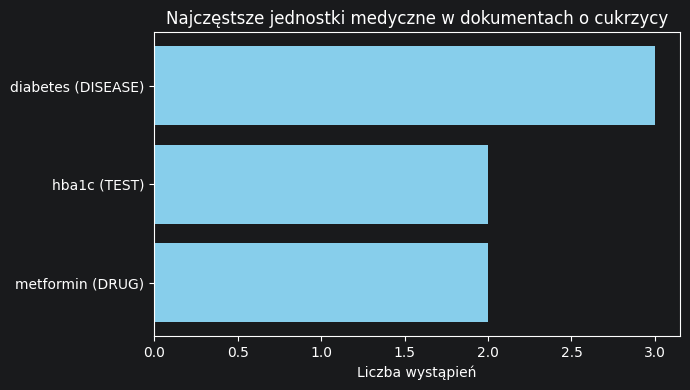

In [48]:
# Zliczanie wystąpienia encji w całym zbiorze
entity_counts = {}
for ents in df["entities"]:
    for ent, label in ents:
        key = f"{ent} ({label})"
        entity_counts[key] = entity_counts.get(key, 0) + 1

# Sortowanie malejące
sorted_entities = sorted(entity_counts.items(), key=lambda x: x[1], reverse=True)
top_entities = dict(sorted_entities[:10])

# Wykres słupkowy
plt.figure()
plt.barh(list(top_entities.keys()), list(top_entities.values()), color="skyblue")
plt.xlabel("Liczba wystąpień")
plt.title("Najczęstsze jednostki medyczne w dokumentach o cukrzycy")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Wyświetlenie przykładowego dokumentu z adnotacjami
print("\nPrzykładowy dokument z oryginalnymi encjami:")
print(f"Tekst: {df.loc[0, 'text']}")
print(f"Encje: {df.loc[0, 'entities']}")


Przykładowy dokument z oryginalnymi encjami:
Tekst: Type 2 diabetes diagnosed 5 years ago. HbA1c = 8.2%. Metformin 1000 mg BID continued, dapagliflozin added. Diet and exercise reinforced.
Encje: [('diabetes', 'DISEASE'), ('hba1c', 'TEST'), ('metformin', 'DRUG')]
